In [2]:
#install YOLOv8 (ultralytrics)
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 25.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 97.2 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 75.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 80.5 MB/s eta 0:00:00:00:0100:01


In [3]:
#import library
from ultralytics import YOLO
import os
import shutil
import random

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
#definisi root dataset ke format YOLO
ROOT = "/kaggle/input/crop-and-weed-detection-data-with-bounding-boxes/agri_data/data" #lokasi awal
DEST = "/kaggle/working/agri-dataset" #lokasi ke format YOLO
IMG_DIR = os.path.join(DEST, "images")
LBL_DIR = os.path.join(DEST, "labels")

In [5]:
#fungsi untuk menyesuiakan gambar dan label ke folder
def move_files(file_list, subset):
    for img in file_list:
        txt = img.replace(".jpeg", ".txt")
        src_img = os.path.join(ROOT, img)
        src_lbl = os.path.join(ROOT, txt)
        
        dst_img = os.path.join(IMG_DIR, subset, img)
        dst_lbl = os.path.join(LBL_DIR, subset, txt)
        
        if os.path.exists(src_lbl):
            shutil.copy(src_img, dst_img)
            shutil.copy(src_lbl, dst_lbl)


In [6]:
#split dataset ke train dan val
for split in ["train", "val"]:
    os.makedirs(os.path.join(IMG_DIR, split), exist_ok=True)
    os.makedirs(os.path.join(LBL_DIR, split), exist_ok=True)

In [7]:
#ambil data .jpeg
jpg_files = [f for f in os.listdir(ROOT) if f.endswith(".jpeg")]
random.shuffle(jpg_files) #acak distrubusi training

In [8]:
#split 80 train 20 val
split_idx = int(len(jpg_files) * 0.8)
train_files = jpg_files[:split_idx]
val_files = jpg_files[split_idx:]

In [9]:
#salin file ke YOLO
move_files(train_files, "train")
move_files(val_files, "val")

In [10]:
# Membuat file konfigurasi data.yaml untuk YOLOv8
data_yaml = '''
train: /kaggle/working/agri-dataset/images/train
val: /kaggle/working/agri-dataset/images/val
nc: 2
names: ['crop', 'weed']
'''
with open('/kaggle/working/agri-dataset/data.yaml', 'w') as f:
    f.write(data_yaml)

Ultralytics 8.3.168 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/agri-dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.003, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0.0, plots=Tr

train: Scanning /kaggle/working/agri-dataset/labels/train.cache... 1040 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1040/1040 [00:00<?, ?it/s]


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 296.1±110.8 MB/s, size: 57.2 KB)


val: Scanning /kaggle/working/agri-dataset/labels/val.cache... 260 images, 0 backgrounds, 0 corrupt: 100%|██████████| 260/260 [00:00<?, ?it/s]


Plotting labels to runs/detect/train2/labels.jpg... 
optimizer: AdamW(lr=0.003, momentum=0.937) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to runs/detect/train2
Starting training for 30 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

      30/30      4.68G     0.9906     0.7491       1.44         44        640: 100%|██████████| 65/65 [00:19<00:00,  3.37it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 9/9 [00:01<00:00,  4.57it/s]

                   all        260        386      0.828      0.781      0.856       0.57



30 epochs completed in 0.183 hours.
Optimizer stripped from runs/detect/train2/weights/last.pt, 22.5MB
Optimizer stripped from runs/detect/train2/weights/best.pt, 22.5MB

Validating runs/detect/train2/weights/best.pt...
Ultralytics 8.3.168 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 9/9 [00:02<00:00,  3.18it/s]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        260        386      0.839      0.791      0.859       0.57
                  crop        133        224      0.836      0.749      0.858        0.6
                  weed        127        162      0.842      0.833       0.86       0.54
Speed: 0.2ms preprocess, 4.5ms inference, 0.0ms loss, 3.1ms postprocess per image
Results saved to runs/detect/train2

image 1/1 /kaggle/working/agri-dataset/images/val/agri_0_5160.jpeg: 640x640 1 weed, 7.8ms
Speed: 2.3ms preprocess, 7.8ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)


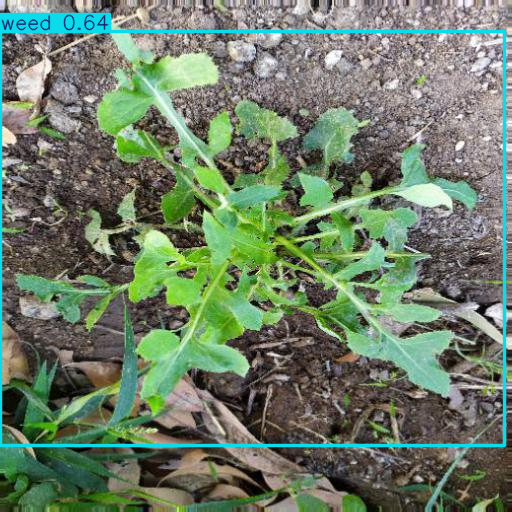

In [12]:
# Training YOLOv8 dengan konfigurasi optimal (training awal)
model = YOLO('yolov8s.pt')
results = model.train(
    data='/kaggle/working/agri-dataset/data.yaml',
    optimizer='AdamW',
    lr0=0.003,
    lrf=0.01,
    epochs=30,
    batch=16,
)

# Inference pada gambar val pertama menggunakan checkpoint hasil training
val_img = os.path.join('/kaggle/working/agri-dataset/images/val', os.listdir('/kaggle/working/agri-dataset/images/val')[0])
model = YOLO('runs/detect/train/weights/best.pt')
pred = model(val_img)
pred[0].show()

In [16]:
!cp runs/detect/train2/weights/best.pt /kaggle/working/best_model2.pt

In [17]:
import pandas as pd

# Load model
model = YOLO('/kaggle/working/best_model2.pt')

# Validasi ulang (jika perlu)
results = model.val(data='/kaggle/working/agri-dataset/data.yaml', split='val')

# Ambil nama kelas
class_names = model.names

# Buat tabel evaluasi
df = pd.DataFrame({
    'Class': [class_names[i] for i in range(results.box.nc)],
    'Precision': results.box.p,
    'Recall': results.box.r,
    'mAP50': results.box.ap50,   # ← tanpa tanda kurung
    'mAP50-95': results.box.ap   # ← tanpa tanda kurung
})

# Tampilkan tabel
df

Ultralytics 8.3.168 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1704.3±109.7 MB/s, size: 59.8 KB)


val: Scanning /kaggle/working/agri-dataset/labels/val.cache... 260 images, 0 backgrounds, 0 corrupt: 100%|██████████| 260/260 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 17/17 [00:03<00:00,  5.21it/s]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        260        386      0.839      0.785      0.859      0.571
                  crop        133        224      0.834      0.737      0.858        0.6
                  weed        127        162      0.844      0.833       0.86      0.542
Speed: 1.2ms preprocess, 5.4ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to runs/detect/val


,Class,Precision,Recall,mAP50,mAP50-95
0,crop,0.833523,0.736607,0.857515,0.600030
1,weed,0.844431,0.833333,0.860413,0.541668


Ultralytics 8.3.168 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/agri-dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=70, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspective=0.0, plots=Tr

train: Scanning /kaggle/working/agri-dataset/labels/train.cache... 1040 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1040/1040 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 589.2±316.5 MB/s, size: 57.2 KB)


val: Scanning /kaggle/working/agri-dataset/labels/val.cache... 260 images, 0 backgrounds, 0 corrupt: 100%|██████████| 260/260 [00:00<?, ?it/s]


...

      70/70         5G     0.9322     0.6726      1.403         27        640: 100%|██████████| 65/65 [00:19<00:00,  3.37it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 9/9 [00:01<00:00,  4.70it/s]

                   all        260        386      0.816      0.813      0.868      0.577



70 epochs completed in 0.425 hours.
Optimizer stripped from runs/detect/train3/weights/last.pt, 22.5MB
Optimizer stripped from runs/detect/train3/weights/best.pt, 22.5MB

Validating runs/detect/train3/weights/best.pt...
Ultralytics 8.3.168 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 9/9 [00:03<00:00,  2.72it/s]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        260        386      0.857      0.785      0.878      0.578
                  crop        133        224      0.853      0.763      0.872      0.604
                  weed        127        162      0.862      0.807      0.883      0.551
Speed: 0.2ms preprocess, 4.5ms inference, 0.0ms loss, 3.2ms postprocess per image
Results saved to runs/detect/train3

image 1/1 /kaggle/working/agri-dataset/images/val/agri_0_5160.jpeg: 640x640 1 weed, 8.7ms
Speed: 2.4ms preprocess, 8.7ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


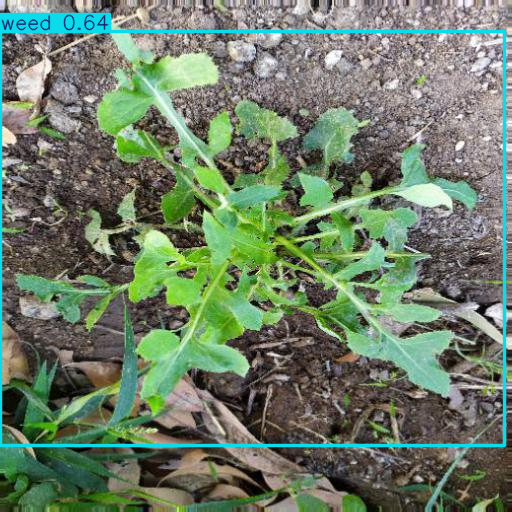

In [18]:
# Training YOLOv8 dengan konfigurasi optimal (training awal) lr0 lebih besar dan epoch langsung besar
model = YOLO('yolov8s.pt')
results = model.train(
    data='/kaggle/working/agri-dataset/data.yaml',
    optimizer='AdamW',
    lr0=0.005,
    lrf=0.01,
    epochs=70,
    batch=16,
)

# Inference pada gambar val pertama menggunakan checkpoint hasil training
val_img = os.path.join('/kaggle/working/agri-dataset/images/val', os.listdir('/kaggle/working/agri-dataset/images/val')[0])
model = YOLO('runs/detect/train/weights/best.pt')
pred = model(val_img)
pred[0].show()

In [19]:
!cp runs/detect/train3/weights/best.pt /kaggle/working/best_model3.pt

In [20]:
# Load model
model = YOLO('/kaggle/working/best_model3.pt')

# Validasi ulang (jika perlu)
results = model.val(data='/kaggle/working/agri-dataset/data.yaml', split='val')

# Ambil nama kelas
class_names = model.names

# Buat tabel evaluasi
df = pd.DataFrame({
    'Class': [class_names[i] for i in range(results.box.nc)],
    'Precision': results.box.p,
    'Recall': results.box.r,
    'mAP50': results.box.ap50,   # ← tanpa tanda kurung
    'mAP50-95': results.box.ap   # ← tanpa tanda kurung
})

# Tampilkan tabel
df

Ultralytics 8.3.168 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1347.8±441.1 MB/s, size: 59.8 KB)


val: Scanning /kaggle/working/agri-dataset/labels/val.cache... 260 images, 0 backgrounds, 0 corrupt: 100%|██████████| 260/260 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 17/17 [00:03<00:00,  5.44it/s]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        260        386      0.857      0.785      0.878      0.578
                  crop        133        224      0.852      0.763      0.872      0.604
                  weed        127        162      0.862      0.807      0.883      0.553
Speed: 1.3ms preprocess, 4.9ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs/detect/val2


,Class,Precision,Recall,mAP50,mAP50-95
0,crop,0.852139,0.763393,0.872251,0.603943
1,weed,0.861650,0.807343,0.882900,0.552952


In [21]:
# Load model dari training sebelumnya
model = YOLO('runs/detect/train3/weights/best.pt')  

# Lanjutkan training dengan setting yang ditingkatkan
model.train(
    data='/kaggle/working/agri-dataset/data.yaml',  # Path ke data.yaml
    epochs=120,                # Latih lebih lama, dikontrol oleh early stopping
    batch=16,                  # Sesuaikan dengan VRAM
    imgsz=640,                 # Resolusi input
    lr0=0.004,                 # Learning rate awal (turun dari 0.005)
    lrf=0.01,                  # Final LR fraction
    optimizer='AdamW',         # Optimizer stabil untuk dataset kecil
    weight_decay=0.001,        # Regularisasi ringan
    patience=20,               # Stop otomatis jika stagnan
    degrees=5,                 # Augmentasi ringan
    translate=0.05,
    scale=0.3,
    shear=1.0,
    flipud=0.2,
    fliplr=0.3,
    mosaic=0.5,
    mixup=0.1
)


Ultralytics 8.3.168 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/agri-dataset/data.yaml, degrees=5, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=120, erasing=0.4, exist_ok=False, fliplr=0.3, flipud=0.2, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.004, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=runs/detect/train3/weights/best.pt, momentum=0.937, mosaic=0.5, multi_scale=False, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=20, per

train: Scanning /kaggle/working/agri-dataset/labels/train.cache... 1040 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1040/1040 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 496.0±326.2 MB/s, size: 57.2 KB)


val: Scanning /kaggle/working/agri-dataset/labels/val.cache... 260 images, 0 backgrounds, 0 corrupt: 100%|██████████| 260/260 [00:00<?, ?it/s]


...

                   all        260        386      0.844      0.806       0.86      0.571
EarlyStopping: Training stopped early as no improvement observed in last 20 epochs. Best results observed at epoch 92, best model saved as best.pt.
To update EarlyStopping(patience=20) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



112 epochs completed in 0.680 hours.
Optimizer stripped from runs/detect/train4/weights/last.pt, 22.5MB
Optimizer stripped from runs/detect/train4/weights/best.pt, 22.5MB

Validating runs/detect/train4/weights/best.pt...
Ultralytics 8.3.168 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 9/9 [00:02<00:00,  3.14it/s]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        260        386      0.819      0.826      0.866      0.583
                  crop        133        224      0.817      0.795      0.845      0.602
                  weed        127        162      0.821      0.858      0.887      0.564
Speed: 0.2ms preprocess, 4.5ms inference, 0.0ms loss, 3.0ms postprocess per image
Results saved to runs/detect/train4


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7985763fded0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [23]:
!cp runs/detect/train4/weights/best.pt /kaggle/working/best_model4.pt

In [24]:
# Load model
model = YOLO('/kaggle/working/best_model4.pt')

# Validasi ulang (jika perlu)
results = model.val(data='/kaggle/working/agri-dataset/data.yaml', split='val')

# Ambil nama kelas
class_names = model.names

# Buat tabel evaluasi
df = pd.DataFrame({
    'Class': [class_names[i] for i in range(results.box.nc)],
    'Precision': results.box.p,
    'Recall': results.box.r,
    'mAP50': results.box.ap50,   # ← tanpa tanda kurung
    'mAP50-95': results.box.ap   # ← tanpa tanda kurung
})

# Tampilkan tabel
df

Ultralytics 8.3.168 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1169.0±346.3 MB/s, size: 59.8 KB)


val: Scanning /kaggle/working/agri-dataset/labels/val.cache... 260 images, 0 backgrounds, 0 corrupt: 100%|██████████| 260/260 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 17/17 [00:03<00:00,  5.17it/s]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        260        386       0.82      0.826      0.866      0.584
                  crop        133        224      0.818      0.795      0.845      0.602
                  weed        127        162      0.821      0.858      0.887      0.565
Speed: 1.1ms preprocess, 5.3ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to runs/detect/val3


,Class,Precision,Recall,mAP50,mAP50-95
0,crop,0.817904,0.794643,0.844737,0.602262
1,weed,0.821097,0.858025,0.887158,0.564824


In [25]:
model = YOLO('yolov8s.pt')  

model.train(
    data='/kaggle/working/agri-dataset/data.yaml',
    epochs=150,
    batch=16,
    imgsz=640,
    lr0=0.004,
    lrf=0.01,
    optimizer='AdamW',
    weight_decay=0.001,
    patience=20,
    degrees=5,
    translate=0.03,
    scale=0.2,
    shear=0.3,
    flipud=0.2,
    fliplr=0.3,
    mosaic=0.3,
    mixup=0.0
)


Ultralytics 8.3.168 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/agri-dataset/data.yaml, degrees=5, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.3, flipud=0.2, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.004, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.3, multi_scale=False, name=train5, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=20, perspective=0.0, plots=True

train: Scanning /kaggle/working/agri-dataset/labels/train.cache... 1040 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1040/1040 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 238.4±132.5 MB/s, size: 57.2 KB)


val: Scanning /kaggle/working/agri-dataset/labels/val.cache... 260 images, 0 backgrounds, 0 corrupt: 100%|██████████| 260/260 [00:00<?, ?it/s]


...

                   all        260        386       0.79      0.812      0.847      0.563
EarlyStopping: Training stopped early as no improvement observed in last 20 epochs. Best results observed at epoch 105, best model saved as best.pt.
To update EarlyStopping(patience=20) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



125 epochs completed in 0.758 hours.
Optimizer stripped from runs/detect/train5/weights/last.pt, 22.5MB
Optimizer stripped from runs/detect/train5/weights/best.pt, 22.5MB

Validating runs/detect/train5/weights/best.pt...
Ultralytics 8.3.168 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 9/9 [00:03<00:00,  2.78it/s]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        260        386      0.804       0.82      0.865       0.58
                  crop        133        224      0.785        0.8      0.846      0.597
                  weed        127        162      0.822       0.84      0.884      0.563
Speed: 0.2ms preprocess, 4.5ms inference, 0.0ms loss, 3.2ms postprocess per image
Results saved to runs/detect/train5


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x798576858890>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [26]:
!cp runs/detect/train5/weights/best.pt /kaggle/working/best_model5.pt

In [29]:
from IPython.display import display
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Daftar model dan path-nya
model_paths = {
    'train2': '/kaggle/working/best_model2.pt',
    'train3': '/kaggle/working/best_model3.pt',
    'train4': '/kaggle/working/best_model4.pt',
    'train5': '/kaggle/working/best_model5.pt',
}

# Path data.yaml
data_yaml = '/kaggle/working/agri-dataset/data.yaml'

# Kumpulan hasil
dfs = []

for name, path in model_paths.items():
    try:
        model = YOLO(path)
        results = model.val(data=data_yaml, split='val')
        class_names = model.names

        df = pd.DataFrame({
            'Model': [name] * results.box.nc,
            'Class': [class_names[i] for i in range(results.box.nc)],
            'Precision': results.box.p,
            'Recall': results.box.r,
            'mAP50': results.box.ap50,
            'mAP50-95': results.box.ap
        })

        dfs.append(df)

    except Exception as e:
        print(f"❌ Gagal evaluasi model {name}: {e}")

# Gabungkan semua jadi satu tabel dan tampilkan
final_result = pd.concat(dfs, ignore_index=True)
display(final_result)


Ultralytics 8.3.168 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1490.2±428.3 MB/s, size: 65.1 KB)


val: Scanning /kaggle/working/agri-dataset/labels/val.cache... 260 images, 0 backgrounds, 0 corrupt: 100%|██████████| 260/260 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 17/17 [00:03<00:00,  5.39it/s]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        260        386      0.839      0.785      0.859      0.571
                  crop        133        224      0.834      0.737      0.858        0.6
                  weed        127        162      0.844      0.833       0.86      0.542
Speed: 1.3ms preprocess, 5.0ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to runs/detect/val5
Ultralytics 8.3.168 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1846.2±618.6 MB/s, size: 65.7 KB)


val: Scanning /kaggle/working/agri-dataset/labels/val.cache... 260 images, 0 backgrounds, 0 corrupt: 100%|██████████| 260/260 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 17/17 [00:03<00:00,  5.42it/s]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        260        386      0.857      0.785      0.878      0.578
                  crop        133        224      0.852      0.763      0.872      0.604
                  weed        127        162      0.862      0.807      0.883      0.553
Speed: 1.3ms preprocess, 4.9ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to runs/detect/val6
Ultralytics 8.3.168 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2064.7±497.2 MB/s, size: 64.5 KB)


val: Scanning /kaggle/working/agri-dataset/labels/val.cache... 260 images, 0 backgrounds, 0 corrupt: 100%|██████████| 260/260 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 17/17 [00:03<00:00,  5.50it/s]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        260        386       0.82      0.826      0.866      0.584
                  crop        133        224      0.818      0.795      0.845      0.602
                  weed        127        162      0.821      0.858      0.887      0.565
Speed: 1.4ms preprocess, 4.8ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to runs/detect/val7
Ultralytics 8.3.168 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1659.7±415.6 MB/s, size: 59.7 KB)


val: Scanning /kaggle/working/agri-dataset/labels/val.cache... 260 images, 0 backgrounds, 0 corrupt: 100%|██████████| 260/260 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 17/17 [00:03<00:00,  5.35it/s]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        260        386      0.804       0.82      0.865       0.58
                  crop        133        224      0.785        0.8      0.846      0.597
                  weed        127        162      0.823       0.84      0.885      0.563
Speed: 1.4ms preprocess, 4.9ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to runs/detect/val8


,Model,Class,Precision,Recall,mAP50,mAP50-95
0,train2,crop,0.833523,0.736607,0.857515,0.600030
1,train2,weed,0.844431,0.833333,0.860413,0.541668
2,train3,crop,0.852139,0.763393,0.872251,0.603943
3,train3,weed,0.861650,0.807343,0.882900,0.552952
4,train4,crop,0.817904,0.794643,0.844737,0.602262
5,train4,weed,0.821097,0.858025,0.887158,0.564824
6,train5,crop,0.785351,0.800358,0.846252,0.597243
7,train5,weed,0.822851,0.839506,0.884576,0.563493


In [30]:
# Load model dari hasil training sebelumnya (train3)
model = YOLO('/kaggle/working/best_model3.pt')

# Lanjutkan training dengan fine-tuning hati-hati
model.train(
    data='/kaggle/working/agri-dataset/data.yaml',  # path data
    epochs=30,                  # Tambahan epoch (bukan total)
    batch=16,                   # Sesuai resource
    imgsz=640,                  # Resolusi standar YOLO
    lr0=0.003,                  # Sedikit lebih rendah dari default
    lrf=0.01,                   # Learning rate final kecil untuk stabil
    optimizer='AdamW',          # Optimizer cocok untuk dataset kecil
    weight_decay=0.001,         # Regularisasi ringan
    patience=20,                # Early stopping
    resume=False,               # Mulai ulang training, bukan resume epoch

    # Augmentasi ringan (cukup untuk mendorong generalisasi)
    degrees=5,
    translate=0.03,
    scale=0.2,
    shear=0.3,
    flipud=0.2,
    fliplr=0.3,
    mosaic=0.2,
    mixup=0.0
)


Ultralytics 8.3.168 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/agri-dataset/data.yaml, degrees=5, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.3, flipud=0.2, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.003, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/best_model3.pt, momentum=0.937, mosaic=0.2, multi_scale=False, name=train6, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=20, perspect

train: Scanning /kaggle/working/agri-dataset/labels/train.cache... 1040 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1040/1040 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 507.5±339.1 MB/s, size: 57.2 KB)


val: Scanning /kaggle/working/agri-dataset/labels/val.cache... 260 images, 0 backgrounds, 0 corrupt: 100%|██████████| 260/260 [00:00<?, ?it/s]


...

                   all        260        386       0.81      0.839      0.873      0.573



30 epochs completed in 0.182 hours.
Optimizer stripped from runs/detect/train6/weights/last.pt, 22.5MB
Optimizer stripped from runs/detect/train6/weights/best.pt, 22.5MB

Validating runs/detect/train6/weights/best.pt...
Ultralytics 8.3.168 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 9/9 [00:02<00:00,  3.19it/s]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        260        386       0.81      0.839      0.873      0.573
                  crop        133        224      0.783      0.826       0.85      0.586
                  weed        127        162      0.836      0.852      0.896      0.561
Speed: 0.2ms preprocess, 4.5ms inference, 0.0ms loss, 3.0ms postprocess per image
Results saved to runs/detect/train6


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x798563b87210>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [31]:
!cp runs/detect/train6/weights/best.pt /kaggle/working/best_model6.pt

In [32]:
from IPython.display import display
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Daftar model dan path-nya
model_paths = {
    'train2': '/kaggle/working/best_model2.pt',
    'train3': '/kaggle/working/best_model3.pt',
    'train4': '/kaggle/working/best_model4.pt',
    'train5': '/kaggle/working/best_model5.pt',
    'train6' :'/kaggle/working/best_model6.pt'
}

# Path data.yaml
data_yaml = '/kaggle/working/agri-dataset/data.yaml'

# Kumpulan hasil
dfs = []

for name, path in model_paths.items():
    try:
        model = YOLO(path)
        results = model.val(data=data_yaml, split='val')
        class_names = model.names

        df = pd.DataFrame({
            'Model': [name] * results.box.nc,
            'Class': [class_names[i] for i in range(results.box.nc)],
            'Precision': results.box.p,
            'Recall': results.box.r,
            'mAP50': results.box.ap50,
            'mAP50-95': results.box.ap
        })

        dfs.append(df)

    except Exception as e:
        print(f"❌ Gagal evaluasi model {name}: {e}")

# Gabungkan semua jadi satu tabel dan tampilkan
final_result = pd.concat(dfs, ignore_index=True)
display(final_result)


Ultralytics 8.3.168 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1147.8±348.4 MB/s, size: 59.8 KB)


val: Scanning /kaggle/working/agri-dataset/labels/val.cache... 260 images, 0 backgrounds, 0 corrupt: 100%|██████████| 260/260 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 17/17 [00:03<00:00,  5.38it/s]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        260        386      0.839      0.785      0.859      0.571
                  crop        133        224      0.834      0.737      0.858        0.6
                  weed        127        162      0.844      0.833       0.86      0.542
Speed: 1.5ms preprocess, 4.9ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to runs/detect/val9
Ultralytics 8.3.168 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1451.7±274.0 MB/s, size: 65.1 KB)


val: Scanning /kaggle/working/agri-dataset/labels/val.cache... 260 images, 0 backgrounds, 0 corrupt: 100%|██████████| 260/260 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 17/17 [00:03<00:00,  5.22it/s]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        260        386      0.857      0.785      0.878      0.578
                  crop        133        224      0.852      0.763      0.872      0.604
                  weed        127        162      0.862      0.807      0.883      0.553
Speed: 1.7ms preprocess, 4.9ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to runs/detect/val10
Ultralytics 8.3.168 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1735.3±552.0 MB/s, size: 65.7 KB)


...

val: Scanning /kaggle/working/agri-dataset/labels/val.cache... 260 images, 0 backgrounds, 0 corrupt: 100%|██████████| 260/260 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 17/17 [00:03<00:00,  5.59it/s]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        260        386      0.804       0.82      0.865       0.58
                  crop        133        224      0.785        0.8      0.846      0.597
                  weed        127        162      0.823       0.84      0.885      0.563
Speed: 1.3ms preprocess, 4.9ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to runs/detect/val12
Ultralytics 8.3.168 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1442.0±611.5 MB/s, size: 59.7 KB)


val: Scanning /kaggle/working/agri-dataset/labels/val.cache... 260 images, 0 backgrounds, 0 corrupt: 100%|██████████| 260/260 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 17/17 [00:03<00:00,  5.65it/s]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        260        386       0.81      0.839      0.873      0.575
                  crop        133        224      0.783      0.826       0.85      0.588
                  weed        127        162      0.836      0.852      0.896      0.562
Speed: 1.4ms preprocess, 4.8ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to runs/detect/val13


,Model,Class,Precision,Recall,mAP50,mAP50-95
0,train2,crop,0.833523,0.736607,0.857515,0.600030
1,train2,weed,0.844431,0.833333,0.860413,0.541668
2,train3,crop,0.852139,0.763393,0.872251,0.603943
3,train3,weed,0.861650,0.807343,0.882900,0.552952
4,train4,crop,0.817904,0.794643,0.844737,0.602262
5,train4,weed,0.821097,0.858025,0.887158,0.564824
6,train5,crop,0.785351,0.800358,0.846252,0.597243
7,train5,weed,0.822851,0.839506,0.884576,0.563493
8,train6,crop,0.783216,0.825893,0.850210,0.587512
9,train6,weed,0.836035,0.851852,0.895581,0.561567


In [33]:
# Load model dari hasil training sebelumnya (train3)
model = YOLO('/kaggle/working/best_model3.pt')

# Lanjutkan training dengan fine-tuning hati-hati
model.train(
    data='/kaggle/working/agri-dataset/data.yaml',  # path data
    epochs=20,                  # Tambahan epoch (bukan total)
    batch=16,                   # Sesuai resource
    imgsz=640,                  # Resolusi standar YOLO
    lr0=0.0025,                  # Sedikit lebih rendah dari default
    lrf=0.01,                   # Learning rate final kecil untuk stabil
    optimizer='AdamW',          # Optimizer cocok untuk dataset kecil
    weight_decay=0.001,         # Regularisasi ringan
    resume=False,               # Mulai ulang training, bukan resume epoch

    # Augmentasi ringan (cukup untuk mendorong generalisasi)
    degrees=5,
    translate=0.03,
    scale=0.15,
    shear=0.1,
    flipud=0.2,
    fliplr=0.3,
    mosaic=0.2,
    mixup=0.0
)

Ultralytics 8.3.168 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/agri-dataset/data.yaml, degrees=5, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.3, flipud=0.2, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0025, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/working/best_model3.pt, momentum=0.937, mosaic=0.2, multi_scale=False, name=train7, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, perspe

train: Scanning /kaggle/working/agri-dataset/labels/train.cache... 1040 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1040/1040 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 390.5±72.2 MB/s, size: 57.2 KB)


val: Scanning /kaggle/working/agri-dataset/labels/val.cache... 260 images, 0 backgrounds, 0 corrupt: 100%|██████████| 260/260 [00:00<?, ?it/s]


...

                   all        260        386      0.813       0.82       0.87      0.568



20 epochs completed in 0.121 hours.
Optimizer stripped from runs/detect/train7/weights/last.pt, 22.5MB
Optimizer stripped from runs/detect/train7/weights/best.pt, 22.5MB

Validating runs/detect/train7/weights/best.pt...
Ultralytics 8.3.168 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 9/9 [00:02<00:00,  3.11it/s]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        260        386      0.818      0.824      0.866      0.571
                  crop        133        224      0.775      0.804      0.848      0.585
                  weed        127        162      0.861      0.844      0.885      0.557
Speed: 0.2ms preprocess, 4.7ms inference, 0.0ms loss, 3.3ms postprocess per image
Results saved to runs/detect/train7


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x798563a45bd0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [34]:
!cp runs/detect/train7/weights/best.pt /kaggle/working/best_model7.pt

In [35]:
from IPython.display import display
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Daftar model dan path-nya
model_paths = {
    'train2': '/kaggle/working/best_model2.pt',
    'train3': '/kaggle/working/best_model3.pt',
    'train4': '/kaggle/working/best_model4.pt',
    'train5': '/kaggle/working/best_model5.pt',
    'train6' :'/kaggle/working/best_model6.pt',
    'train7' :'/kaggle/working/best_model7.pt',

}

# Path data.yaml
data_yaml = '/kaggle/working/agri-dataset/data.yaml'

# Kumpulan hasil
dfs = []

for name, path in model_paths.items():
    try:
        model = YOLO(path)
        results = model.val(data=data_yaml, split='val')
        class_names = model.names

        df = pd.DataFrame({
            'Model': [name] * results.box.nc,
            'Class': [class_names[i] for i in range(results.box.nc)],
            'Precision': results.box.p,
            'Recall': results.box.r,
            'mAP50': results.box.ap50,
            'mAP50-95': results.box.ap
        })

        dfs.append(df)

    except Exception as e:
        print(f"❌ Gagal evaluasi model {name}: {e}")

# Gabungkan semua jadi satu tabel dan tampilkan
final_result = pd.concat(dfs, ignore_index=True)
display(final_result)


Ultralytics 8.3.168 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1279.5±494.3 MB/s, size: 59.8 KB)


val: Scanning /kaggle/working/agri-dataset/labels/val.cache... 260 images, 0 backgrounds, 0 corrupt: 100%|██████████| 260/260 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 17/17 [00:03<00:00,  5.17it/s]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        260        386      0.839      0.785      0.859      0.571
                  crop        133        224      0.834      0.737      0.858        0.6
                  weed        127        162      0.844      0.833       0.86      0.542
Speed: 1.6ms preprocess, 4.9ms inference, 0.0ms loss, 1.8ms postprocess per image
Results saved to runs/detect/val14
Ultralytics 8.3.168 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1612.1±314.7 MB/s, size: 65.1 KB)


val: Scanning /kaggle/working/agri-dataset/labels/val.cache... 260 images, 0 backgrounds, 0 corrupt: 100%|██████████| 260/260 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 17/17 [00:03<00:00,  5.39it/s]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        260        386      0.857      0.785      0.878      0.578
                  crop        133        224      0.852      0.763      0.872      0.604
                  weed        127        162      0.862      0.807      0.883      0.553
Speed: 1.4ms preprocess, 4.9ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to runs/detect/val15
Ultralytics 8.3.168 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1716.5±401.3 MB/s, size: 65.7 KB)


...

val: Scanning /kaggle/working/agri-dataset/labels/val.cache... 260 images, 0 backgrounds, 0 corrupt: 100%|██████████| 260/260 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 17/17 [00:03<00:00,  5.54it/s]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        260        386       0.81      0.839      0.873      0.575
                  crop        133        224      0.783      0.826       0.85      0.588
                  weed        127        162      0.836      0.852      0.896      0.562
Speed: 1.5ms preprocess, 4.8ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to runs/detect/val18
Ultralytics 8.3.168 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 72 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1887.1±529.6 MB/s, size: 64.0 KB)


val: Scanning /kaggle/working/agri-dataset/labels/val.cache... 260 images, 0 backgrounds, 0 corrupt: 100%|██████████| 260/260 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 17/17 [00:03<00:00,  5.49it/s]
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


                   all        260        386      0.818      0.824      0.867      0.572
                  crop        133        224      0.775      0.804      0.848      0.584
                  weed        127        162      0.861      0.844      0.885       0.56
Speed: 1.4ms preprocess, 5.0ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs/detect/val19


,Model,Class,Precision,Recall,mAP50,mAP50-95
0,train2,crop,0.833523,0.736607,0.857515,0.600030
1,train2,weed,0.844431,0.833333,0.860413,0.541668
2,train3,crop,0.852139,0.763393,0.872251,0.603943
3,train3,weed,0.861650,0.807343,0.882900,0.552952
4,train4,crop,0.817904,0.794643,0.844737,0.602262
5,train4,weed,0.821097,0.858025,0.887158,0.564824
6,train5,crop,0.785351,0.800358,0.846252,0.597243
7,train5,weed,0.822851,0.839506,0.884576,0.563493
8,train6,crop,0.783216,0.825893,0.850210,0.587512
9,train6,weed,0.836035,0.851852,0.895581,0.561567



image 1/1 /kaggle/working/agri-dataset/images/val/agri_0_1130.jpeg: 640x640 2 weeds, 8.4ms
Speed: 2.5ms preprocess, 8.4ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/agri-dataset/images/val/agri_0_1130.jpeg: 640x640 2 weeds, 8.4ms
Speed: 2.3ms preprocess, 8.4ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/agri-dataset/images/val/agri_0_1130.jpeg: 640x640 2 weeds, 8.5ms
Speed: 2.3ms preprocess, 8.5ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/agri-dataset/images/val/agri_0_1130.jpeg: 640x640 2 weeds, 8.4ms
Speed: 2.6ms preprocess, 8.4ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/agri-dataset/images/val/agri_0_1130.jpeg: 640x640 2 weeds, 8.4ms
Speed: 2.3ms preprocess, 8.4ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /kaggle/working/agri-dataset/images/val/agri_0_11

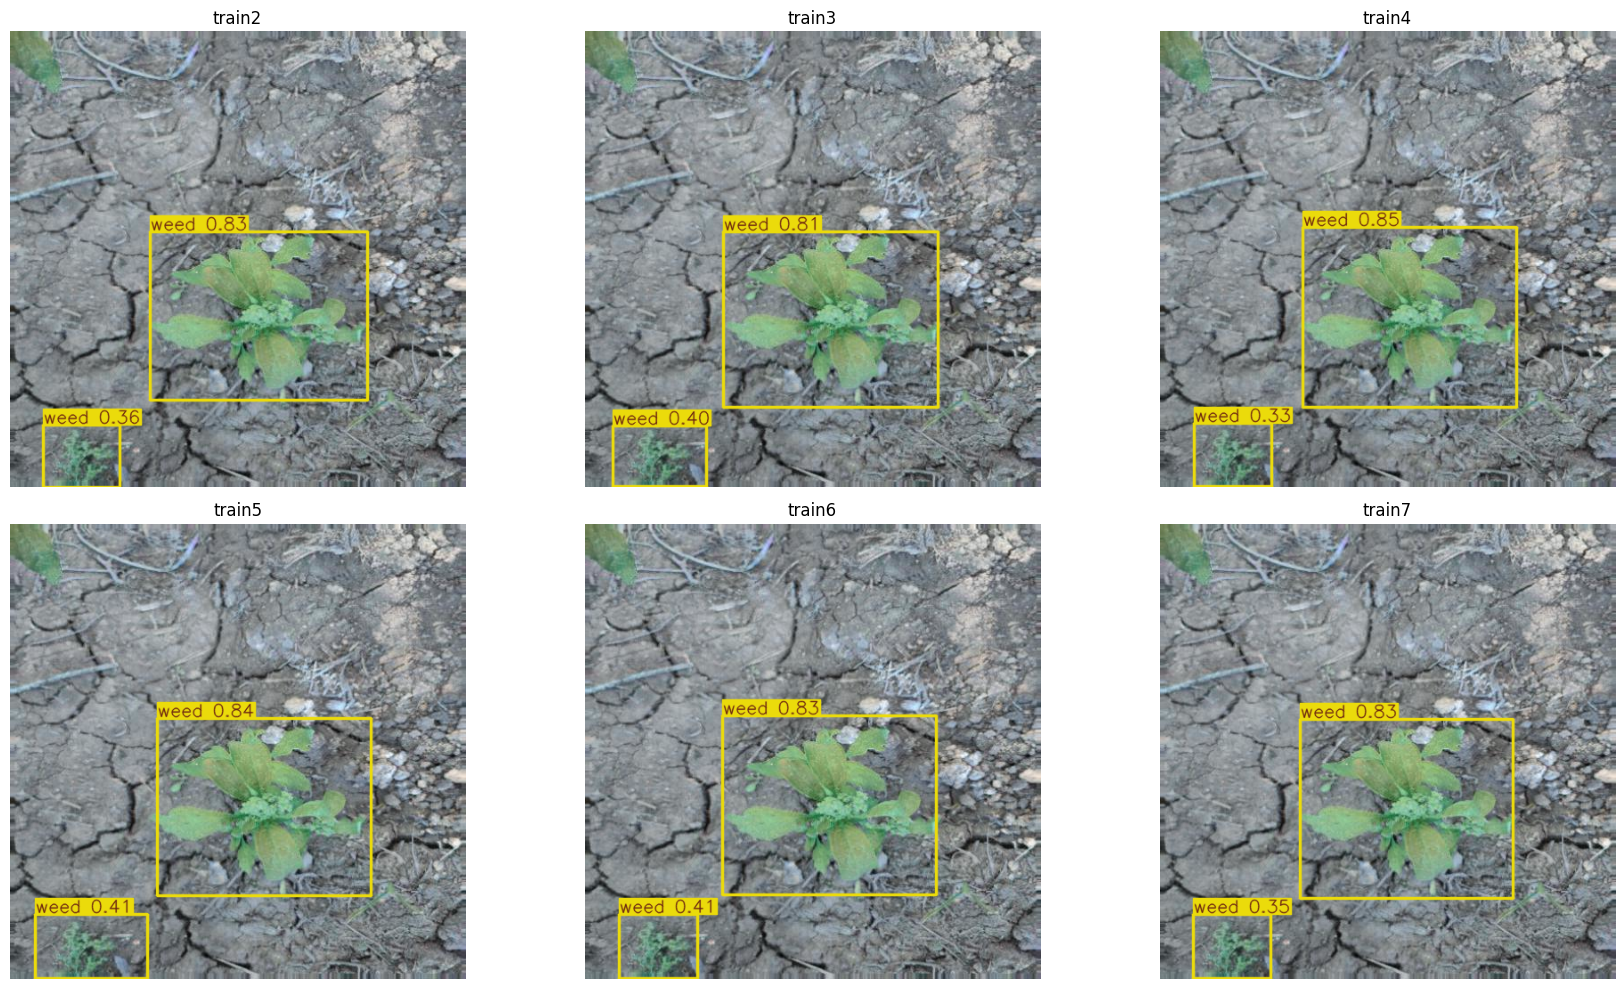

In [36]:
import matplotlib.pyplot as plt
import cv2

# Path gambar untuk diuji
image_path = '/kaggle/working/agri-dataset/images/val/agri_0_1130.jpeg'

# Daftar model yang ingin dibandingkan
model_paths = {
    'train2': '/kaggle/working/best_model2.pt',
    'train3': '/kaggle/working/best_model3.pt',
    'train4': '/kaggle/working/best_model4.pt',
    'train5': '/kaggle/working/best_model5.pt',
    'train6': '/kaggle/working/best_model6.pt',
    'train7': '/kaggle/working/best_model7.pt'
}

# Gambar input asli
orig_img = cv2.imread(image_path)[..., ::-1]

# Setup plot
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Loop dan tampilkan hasil tiap model
for idx, (name, path) in enumerate(model_paths.items()):
    model = YOLO(path)
    results = model(image_path)
    rendered = results[0].plot()  # hasil deteksi

    axes[idx].imshow(rendered)
    axes[idx].set_title(name)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
model = YOLO('runs/detect/train/weights/best.pt')
results = model.train(
    data='/kaggle/working/agri-dataset/data.yaml',
    optimizer='AdamW',
    lr0=0.0005,
    lrf=0.01,
    epochs=50,  # model mulai dari awal
    batch=16,
)


In [ ]:
# Fine-tuning dari train2 (berbasis yolov8s)
from ultralytics import YOLO

model = YOLO('runs/detect/train2/weights/best.pt') #lanjutan dari train2 lr0 003 dan 30 epoch
results = model.train(
    data='/kaggle/working/agri-dataset/data.yaml',
    optimizer='AdamW',
    lr0=0.0005,     # Fine-tune learning rate di buat lebih kecil dari 003
    lrf=0.01,
    epochs=50,      # Tambah 50 epoch
    batch=16
)


In [ ]:
from ultralytics import YOLO

model = YOLO('runs/detect/train6/weights/best.pt')

# Jalankan inferensi pada gambar tertentu
result = model('/kaggle/working/agri-dataset/images/val/agri_0_4778.jpeg')
result[0].show()


In [ ]:
!cp runs/detect/train6/weights/best.pt /kaggle/working/best_model.pt


In [ ]:
model.val()  # Evaluasi penuh


In [ ]:
from ultralytics import YOLO

model = YOLO('runs/detect/train6/weights/best.pt')
results = model.train(
    data='/kaggle/working/agri-dataset/data.yaml',
    optimizer='AdamW',  
    lr0=0.0003,          # turunkan learning rate untuk fine-tuning
    lrf=0.01,
    epochs=30,           # tambah 30 
    batch=16,
    patience=10,         # early stopping jika tidak ada peningkatan
)


In [ ]:
from ultralytics import YOLO

# Muat model dari hasil best sebelumnya
model = YOLO('runs/detect/train7/weights/best.pt')

# Fine-tune lebih dalam dengan learning rate lebih rendah
results = model.train(
    data='/kaggle/working/agri-dataset/data.yaml',
    epochs=40,              # Tambahan 40 epoch
    batch=16,
    lr0=0.00015,            # Learning rate lebih kecil agar perubahan lebih halus
    lrf=0.01,               # Default final LR fraction
    optimizer='AdamW',      # Optimizer yang sama
    patience=20,            # EarlyStopping lebih sabar, agar tidak berhenti terlalu cepat
    save=True,              # Simpan hasil terbaik
)


In [ ]:
from ultralytics import YOLO

model = YOLO('runs/detect/train3/weights/best.pt')

# Jalankan inferensi pada gambar tertentu
result = model('/kaggle/working/agri-dataset/images/val/agri_0_4778.jpeg')
result[0].show()

In [ ]:
from ultralytics import YOLO

model = YOLO('runs/detect/train5/weights/best.pt')

# Jalankan inferensi pada gambar tertentu
result = model('/kaggle/working/agri-dataset/images/val/agri_0_4778.jpeg')
result[0].show()

In [ ]:
from ultralytics import YOLO

model = YOLO('runs/detect/train6/weights/best.pt')

# Jalankan inferensi pada gambar tertentu
result = model('/kaggle/working/agri-dataset/images/val/agri_0_4778.jpeg')
result[0].show()

In [ ]:
from ultralytics import YOLO

model = YOLO('runs/detect/train7/weights/best.pt')

# Jalankan inferensi pada gambar tertentu
result = model('/kaggle/working/agri-dataset/images/val/agri_0_4778.jpeg')
result[0].show()

In [ ]:
from ultralytics import YOLO

model = YOLO('runs/detect/train8/weights/best.pt')

# Jalankan inferensi pada gambar tertentu
result = model('/kaggle/working/agri-dataset/images/val/agri_0_4778.jpeg')
result[0].show()

In [ ]:
!cp runs/detect/train7/weights/best.pt /kaggle/working/best_model_train7.pt
!cp runs/detect/train6/weights/best.pt /kaggle/working/best_model_train6.pt

In [ ]:
from ultralytics import YOLO

# Load model dari train7
model = YOLO('runs/detect/train7/weights/best.pt')

# Fine-tune dengan augmentasi tambahan
model.train(
    data='/kaggle/working/agri-dataset/data.yaml',  # path ke YAML dataset kamu
    epochs=100,
    imgsz=640,
    batch=16,
    name='train9_augmented',
    pretrained=True,
    degrees=10,         # rotasi
    translate=0.1,      # translasi gambar
    scale=0.5,          # scaling objek
    shear=2.0,          # shear transform
    perspective=0.0005, # perspektif
    flipud=0.5,         # flip vertikal
    fliplr=0.5,         # flip horizontal
    mosaic=0.8,         # mosaic (gabung 4 gambar)
    mixup=0.1,          # mixup antar gambar
    patience=20         # early stopping jika tidak membaik
)


In [ ]:
from ultralytics import YOLO

model = YOLO('runs/detect/train9_augmented/weights/best.pt')

# Jalankan inferensi pada gambar tertentu
result = model('/kaggle/working/agri-dataset/images/val/agri_0_4778.jpeg')
result[0].show()

In [ ]:
!cp runs/detect/train9_augmented/weights/best.pt /kaggle/working/best_augmented9.pt


In [ ]:
from IPython.display import FileLink
FileLink('/kaggle/working/best_augmented9.pt')


In [ ]:
from ultralytics import YOLO
import pandas as pd

# Load model
model = YOLO('/kaggle/working/best_augmented9.pt')

# Validasi ulang (jika perlu)
results = model.val(data='/kaggle/working/agri-dataset/data.yaml', split='val')

# Ambil nama kelas
class_names = model.names

# Buat tabel evaluasi
df = pd.DataFrame({
    'Class': [class_names[i] for i in range(results.box.nc)],
    'Precision': results.box.p,
    'Recall': results.box.r,
    'mAP50': results.box.ap50,   # ← tanpa tanda kurung
    'mAP50-95': results.box.ap   # ← tanpa tanda kurung
})

# Tampilkan tabel
df


In [ ]:
from ultralytics import YOLO

# Load model terbaik dari hasil augmentasi sebelumnya (train9_augmented)
model = YOLO('runs/detect/train9_augmented/weights/best.pt')

# Lanjutkan fine-tuning dengan penyesuaian (augmentasi tetap bisa diterapkan)
model.train(
    data='/kaggle/working/agri-dataset/data.yaml',
    epochs=50,                  # Lanjutkan 50 epoch lagi
    imgsz=640,
    batch=16,
    name='train10_augmented',  # Output folder baru
    pretrained=True,           # Tetap gunakan bobot pretrained dari train9
    lr0=0.0001,                 # Learning rate lebih rendah lagi (stabilisasi)
    lrf=0.01,
    degrees=10,
    translate=0.1,
    scale=0.5,
    shear=2.0,
    perspective=0.0005,
    flipud=0.5,
    fliplr=0.5,
    mosaic=0.7,
    mixup=0.1,
    optimizer='AdamW',
    patience=30
)


In [ ]:
!cp runs/detect/train10_augmented/weights/best.pt /kaggle/working/best_augmented10.pt

In [ ]:
from ultralytics import YOLO

model = YOLO('runs/detect/train10_augmented/weights/best.pt')

# Jalankan inferensi pada gambar tertentu
result = model('/kaggle/working/agri-dataset/images/val/agri_0_4778.jpeg')
result[0].show()

In [ ]:
from ultralytics import YOLO
import pandas as pd

# Load model
model = YOLO('/kaggle/working/best_augmented10.pt')

# Validasi ulang (jika perlu)
results = model.val(data='/kaggle/working/agri-dataset/data.yaml', split='val')

# Ambil nama kelas
class_names = model.names

# Buat tabel evaluasi
df = pd.DataFrame({
    'Class': [class_names[i] for i in range(results.box.nc)],
    'Precision': results.box.p,
    'Recall': results.box.r,
    'mAP50': results.box.ap50,   # ← tanpa tanda kurung
    'mAP50-95': results.box.ap   # ← tanpa tanda kurung
})

# Tampilkan tabel
df

In [ ]:
from ultralytics import YOLO

model = YOLO('runs/detect/train10_augmented/weights/best.pt')

# Jalankan inferensi pada gambar tertentu
result = model('/kaggle/working/agri-dataset/images/val/agri_0_14.jpeg')
result[0].show()